In [1]:
library(tidyverse)
library(vroom)
library(data.table)
library(future.apply)

figure_outdir <- "/mnt/dawnccle2/melange/figures_outputs/fig06"
# Create the output directory if it doesn't exist.
if (!dir.exists(figure_outdir)) {
  dir.create(figure_outdir, recursive = TRUE)
}

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.0.4     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘vroom’


The following objects are masked from ‘package:readr’:

    as.col_spec, col_character, col_date, col_datetime, col_double,
    col_factor, col_guess, col_integer, col_logical, col_number,
    col_skip, col_time, cols, cols_condense, cols_only, date_names,
    date_names_lang, date_names_langs, default_locale, fwf_cols,
    fwf_empty, fwf_positions, fwf_widths, locale, output_column,
    problems, spec



Attaching package: ‘data.table’


The

# Now analyze the data

In [2]:
raw_df <- read.csv("/mnt/dawnccle2/processed_data/reprocess_250221/count_normalized_satmutv2_dawn/satmutv2_dawn_all_samples_raw_counts.csv")
head(raw_df)

,filename,index,offset_initial,design,mode,offset,count,count_scaled,sample,condition
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<chr>,<chr>
1,/mnt/dawnccle2/processed_data/satmutv2_dawn//satmutv2_A375_rep1_S1_umi_dedup_fine_grained_idx.csv,ENSG00000001617.12;SEMA3F;chr3-50174051-50174114-50173792-50173953-50174230-50174350,0:0:0,R1design0,INCLUDED,0:-14:0,1,1,A375-rep1,A375
2,/mnt/dawnccle2/processed_data/satmutv2_dawn//satmutv2_A375_rep1_S1_umi_dedup_fine_grained_idx.csv,ENSG00000001617.12;SEMA3F;chr3-50174051-50174114-50173792-50173953-50174230-50174350,0:0:0,R1design0,INCLUDED,0:0:0,62,62,A375-rep1,A375
3,/mnt/dawnccle2/processed_data/satmutv2_dawn//satmutv2_A375_rep1_S1_umi_dedup_fine_grained_idx.csv,ENSG00000001617.12;SEMA3F;chr3-50174051-50174114-50173792-50173953-50174230-50174350,0:0:0,R1design0,SKIPPED,0,99,99,A375-rep1,A375
4,/mnt/dawnccle2/processed_data/satmutv2_dawn//satmutv2_A375_rep1_S1_umi_dedup_fine_grained_idx.csv,ENSG00000001617.12;SEMA3F;chr3-50174051-50174114-50173792-50173953-50174230-50174350,0:0:0,R1design0,UNSPLICED,0,1,1,A375-rep1,A375
5,/mnt/dawnccle2/processed_data/satmutv2_dawn//satmutv2_A375_rep1_S1_umi_dedup_fine_grained_idx.csv,ENSG00000001617.12;SEMA3F;chr3-50174051-50174114-50173792-50173953-50174230-50174350,0:0:0,R1design0,UNSPLICED,113,1,1,A375-rep1,A375
6,/mnt/dawnccle2/processed_data/satmutv2_dawn//satmutv2_A375_rep1_S1_umi_dedup_fine_grained_idx.csv,ENSG00000001617.12;SEMA3F;chr3-50174051-50174114-50173792-50173953-50174230-50174350,0:0:0,vae_0_to_10_R1design10,INCLUDED,10:-25:0,3,3,A375-rep1,A375


In [3]:
raw_df_clean <- raw_df %>%
    mutate(index_offset = paste0(index, "__", offset_initial)) %>% 
    select(-filename, - index, - offset_initial) %>%
    filter(mode %in% c("INCLUDED", "SKIPPED")) %>% 
    group_by(sample, condition, index_offset, mode, offset, design) %>%
    summarise(count = sum(count)) %>% 
    arrange(sample, condition, index_offset, design)
head(raw_df_clean)

`summarise()` has grouped output by 'sample', 'condition', 'index_offset',
'mode', 'offset'. You can override using the `.groups` argument.


sample,condition,index_offset,mode,offset,design,count
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>
A375-rep1,A375,ENSG00000001617.12;SEMA3F;chr3-50174051-50174114-50173792-50173953-50174230-50174350__0:0:0,INCLUDED,0:-14:0,R1design0,1
A375-rep1,A375,ENSG00000001617.12;SEMA3F;chr3-50174051-50174114-50173792-50173953-50174230-50174350__0:0:0,INCLUDED,0:0:0,R1design0,62
A375-rep1,A375,ENSG00000001617.12;SEMA3F;chr3-50174051-50174114-50173792-50173953-50174230-50174350__0:0:0,SKIPPED,0,R1design0,99
A375-rep1,A375,ENSG00000001617.12;SEMA3F;chr3-50174051-50174114-50173792-50173953-50174230-50174350__0:0:0,INCLUDED,10:-25:0,vae_0_to_10_R1design10,3
A375-rep1,A375,ENSG00000001617.12;SEMA3F;chr3-50174051-50174114-50173792-50173953-50174230-50174350__0:0:0,INCLUDED,10:2:0,vae_0_to_10_R1design10,1374
A375-rep1,A375,ENSG00000001617.12;SEMA3F;chr3-50174051-50174114-50173792-50173953-50174230-50174350__0:0:0,SKIPPED,0,vae_0_to_10_R1design10,53


In [4]:
raw_df_to_psi <- raw_df_clean %>% 
    group_by(sample, condition, index_offset, mode, design) %>%
    summarise(count = sum(count)) %>% 
    ungroup() %>% 
    pivot_wider(names_from = mode, values_from = count, values_fill = 0) %>%
    mutate(total_counts = INCLUDED + SKIPPED) %>%
    mutate(included_count_normalized = as.integer(INCLUDED/total_counts * 1000)) %>% 
    mutate(skipped_count_normalized = as.integer(SKIPPED/total_counts * 1000)) %>% 
    filter(total_counts >= 30) %>%
    mutate(PSI = log2((included_count_normalized+1) / (skipped_count_normalized+1)))

head(raw_df_to_psi)

`summarise()` has grouped output by 'sample', 'condition', 'index_offset',
'mode'. You can override using the `.groups` argument.


sample,condition,index_offset,design,INCLUDED,SKIPPED,total_counts,included_count_normalized,skipped_count_normalized,PSI
<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<int>,<int>,<dbl>
A375-rep1,A375,ENSG00000001617.12;SEMA3F;chr3-50174051-50174114-50173792-50173953-50174230-50174350__0:0:0,R1design0,63,99,162,388,611,-0.6537615
A375-rep1,A375,ENSG00000001617.12;SEMA3F;chr3-50174051-50174114-50173792-50173953-50174230-50174350__0:0:0,vae_0_to_10_R1design10,1377,53,1430,962,37,4.6634645
A375-rep1,A375,ENSG00000001617.12;SEMA3F;chr3-50174051-50174114-50173792-50173953-50174230-50174350__0:0:0,vae_0_to_10_R1design11,927,38,965,960,39,4.5864645
A375-rep1,A375,ENSG00000001617.12;SEMA3F;chr3-50174051-50174114-50173792-50173953-50174230-50174350__0:0:0,vae_0_to_10_R1design12,307,22,329,933,66,3.8011895
A375-rep1,A375,ENSG00000001617.12;SEMA3F;chr3-50174051-50174114-50173792-50173953-50174230-50174350__0:0:0,vae_0_to_10_R1design13,248,9,257,964,35,4.7444601
A375-rep1,A375,ENSG00000001617.12;SEMA3F;chr3-50174051-50174114-50173792-50173953-50174230-50174350__0:0:0,vae_0_to_10_R1design14,808,20,828,975,24,5.2868811


Warning message:
“Removed 633 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 633 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 533 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 533 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 2956 rows containing missing values or values outside the scale range
(`geom_point()`).”


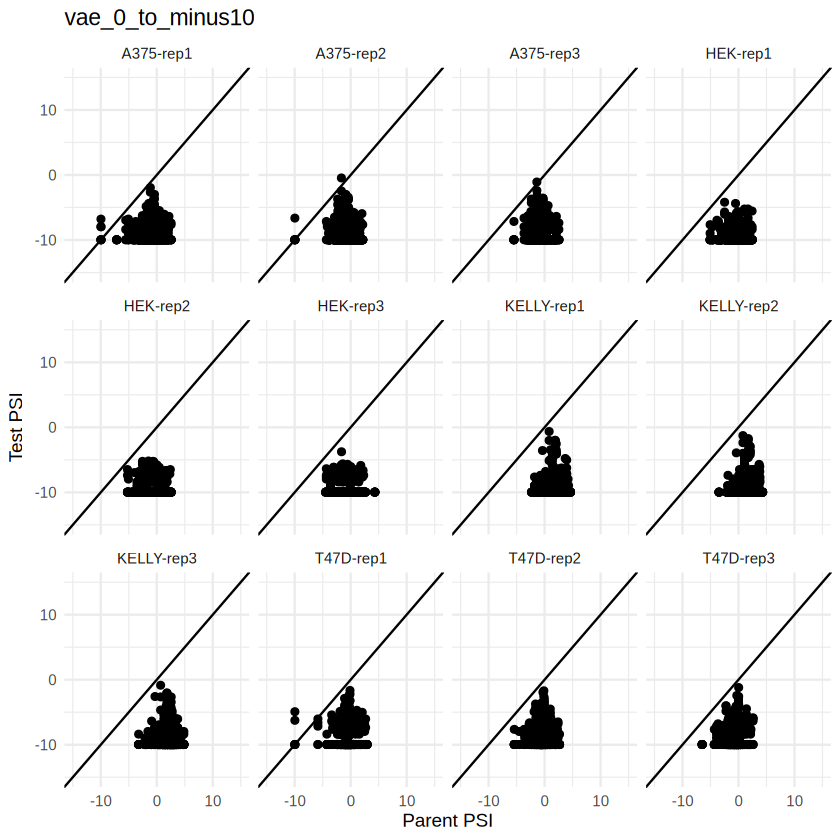

Warning message:
“Removed 2956 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 4066 rows containing missing values or values outside the scale range
(`geom_point()`).”


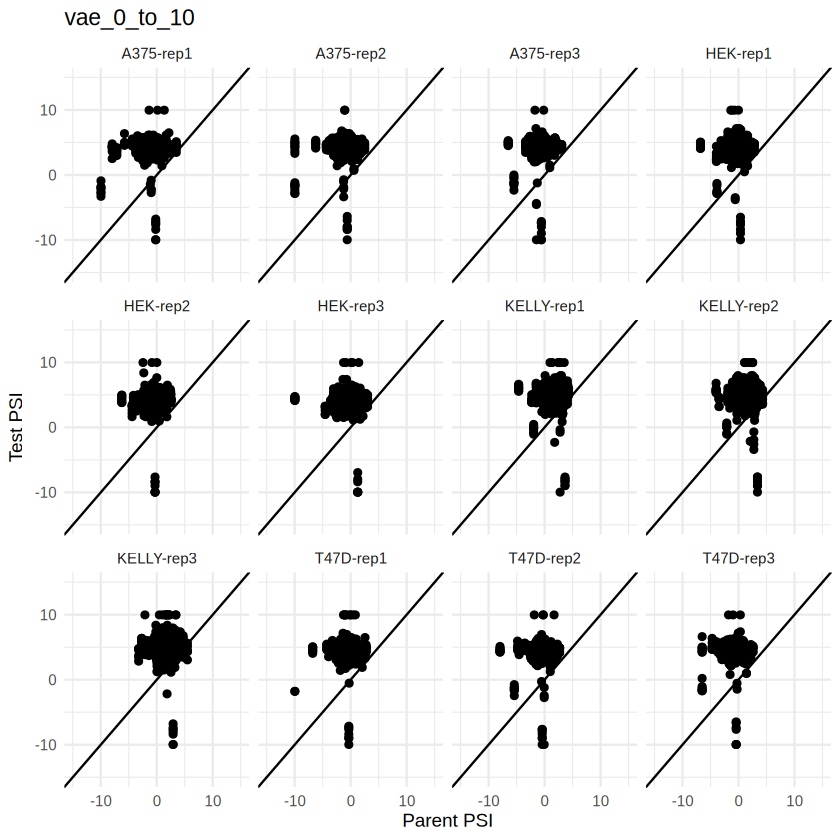

Warning message:
“Removed 4066 rows containing missing values or values outside the scale range
(`geom_point()`).”


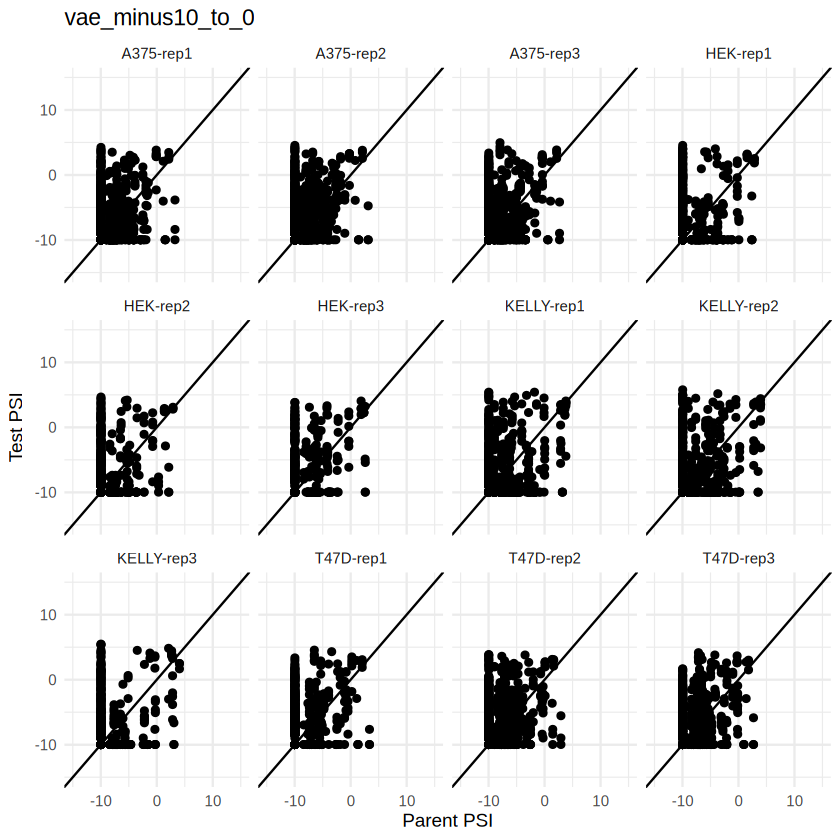

Warning message:
“Removed 59 rows containing missing values or values outside the scale range
(`geom_point()`).”


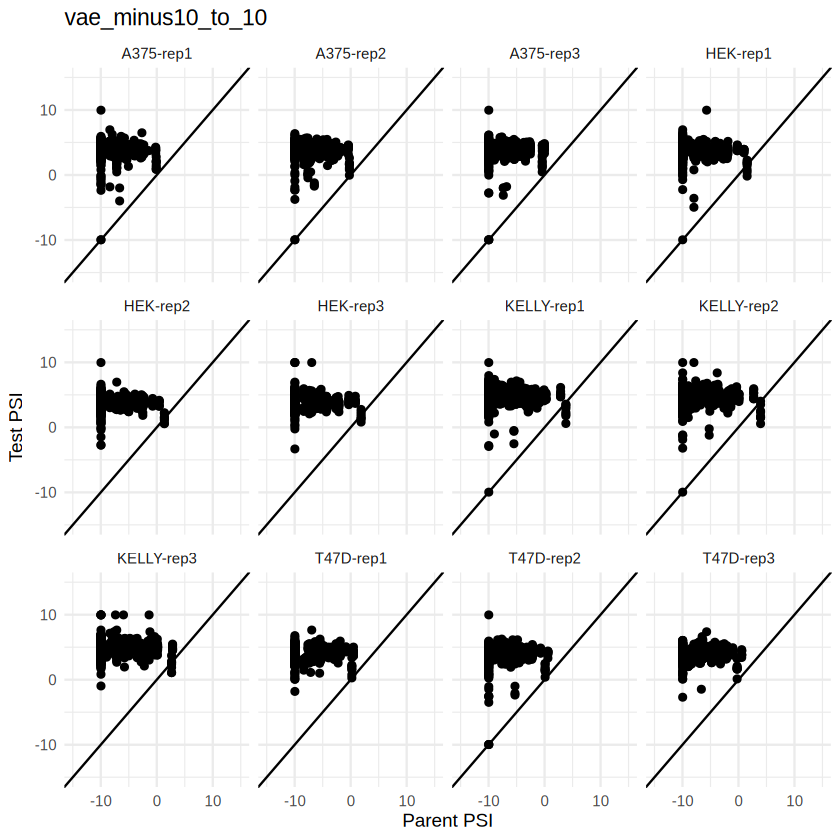

Warning message:
“Removed 59 rows containing missing values or values outside the scale range
(`geom_point()`).”


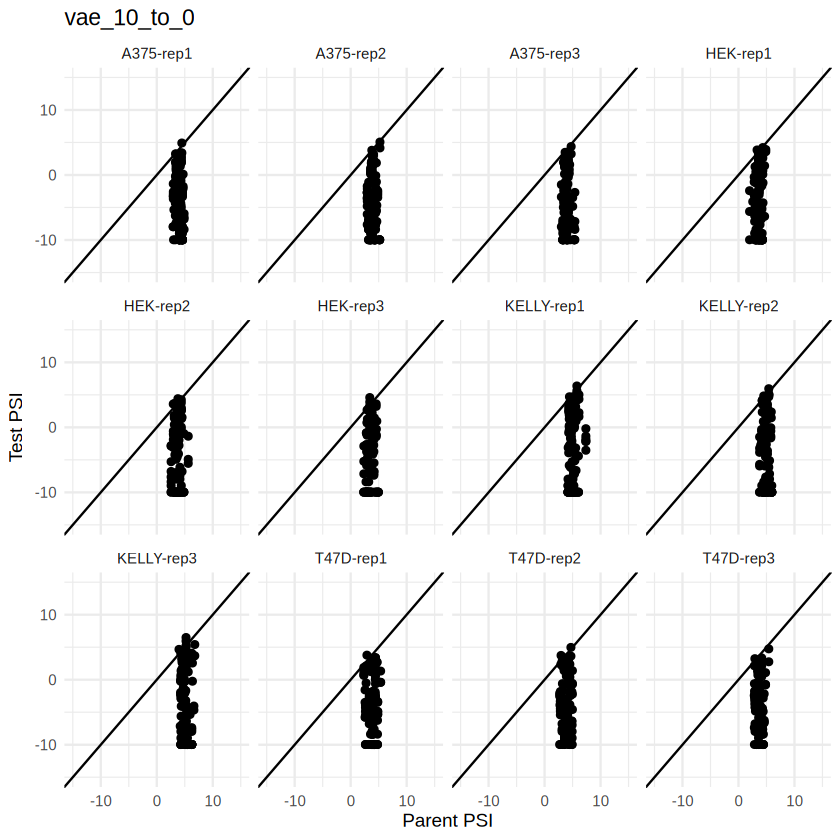

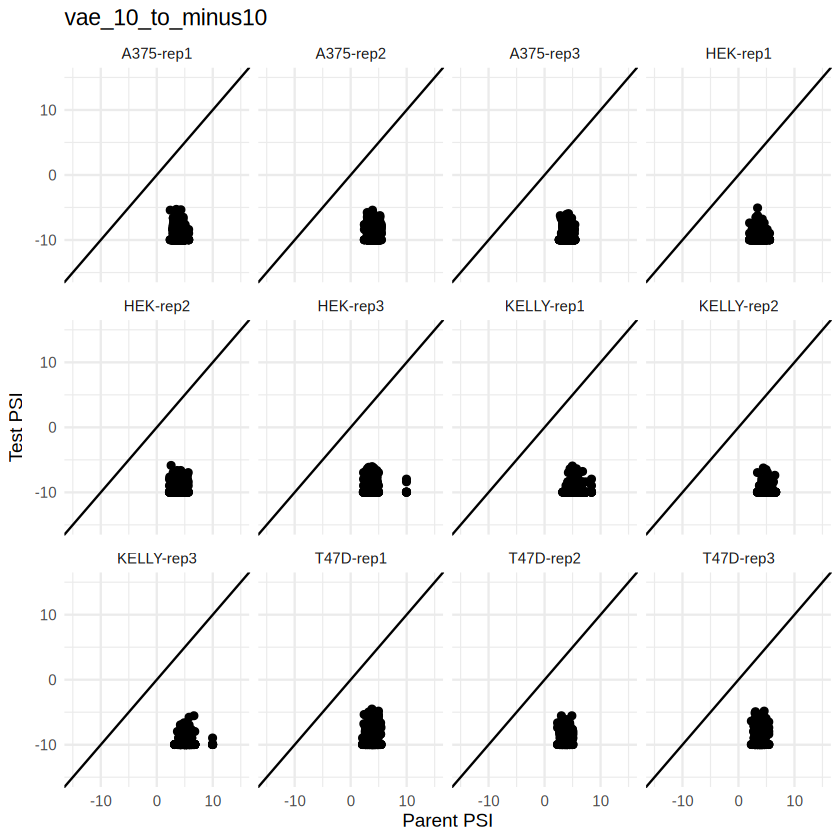

In [5]:
# Get the standard set. 
standard_set <- raw_df_to_psi %>% 
    filter(design == "R1design0") %>% 
    mutate(parent_PSI = PSI) %>%
    select(sample, condition, index_offset, parent_PSI)
    
test_set <- raw_df_to_psi %>% 
    filter(design != "R1design0") 

merged_back <- merge(test_set, standard_set, by = c("sample", "condition", "index_offset"), all.x = TRUE)

categories <- c("vae_0_to_minus10", "vae_0_to_10", "vae_minus10_to_0", "vae_minus10_to_10", "vae_10_to_0", "vae_10_to_minus10")

output_filepath <- "/mnt/dawnccle2/melange/figures_outputs/R1_vae_validation"
# Create the output directory if it doesn't exist.
if (!dir.exists(output_filepath)) {
  dir.create(output_filepath, recursive = TRUE)
}

# Loop through each category and create/save plots
for(category_current in categories) {
    data_current <- merged_back %>%
        filter(grepl(category_current, design))
    
    p <- ggplot(data_current, aes(x = parent_PSI, y = PSI)) +
        geom_point() +
        geom_abline(slope = 1, intercept = 0) +
        theme_minimal() +
        labs(x = "Parent PSI", y = "Test PSI") +
        ggtitle(category_current) + 
        facet_wrap(~sample) + 
        xlim(-15, 15) +
        ylim(-15, 15)
    
    # Save plot
    ggsave(
        filename = file.path(output_filepath, 
                           paste0(category_current, "_plot.pdf")),
        plot = p,
        width = 12,
        height = 8
    )
    
    # Display plot in notebook
    print(p)
}


# Look at correctness metrics - first based on hard cut offs

`summarise()` has grouped output by 'sample'. You can override using the
`.groups` argument.
`summarise()` has grouped output by 'sample'. You can override using the
`.groups` argument.
`summarise()` has grouped output by 'sample'. You can override using the
`.groups` argument.
`summarise()` has grouped output by 'sample'. You can override using the
`.groups` argument.
`summarise()` has grouped output by 'sample'. You can override using the
`.groups` argument.


`summarise()` has grouped output by 'sample'. You can override using the
`.groups` argument.
`summarise()` has grouped output by 'category'. You can override using the
`.groups` argument.


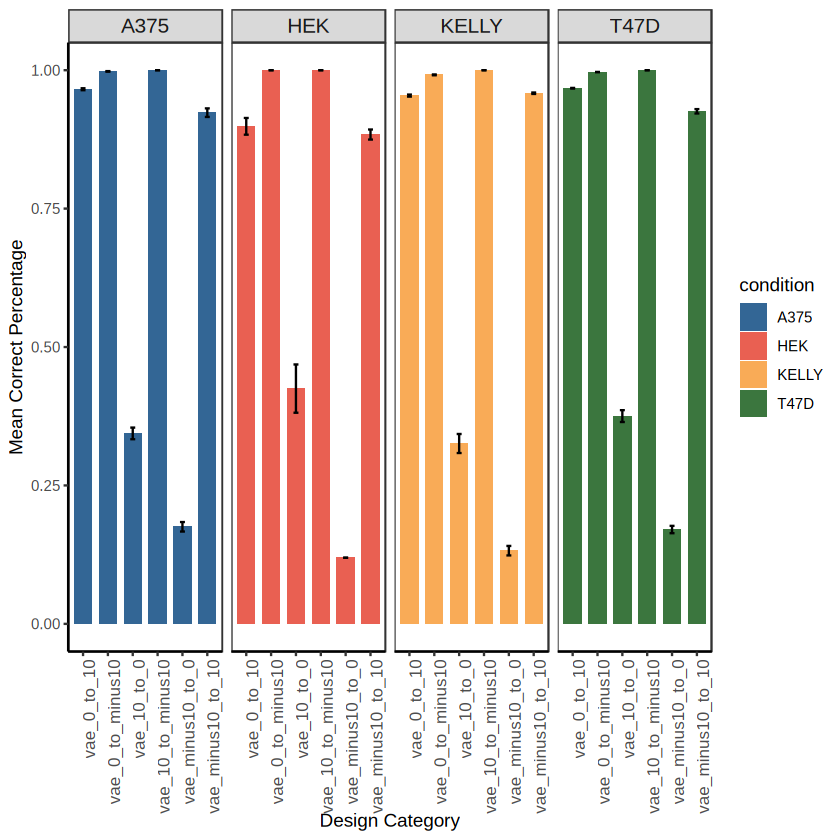

In [6]:
categories <- c("vae_0_to_minus10", "vae_0_to_10", "vae_minus10_to_0", "vae_minus10_to_10", "vae_10_to_0", "vae_10_to_minus10")

# vae_0_to_minus10
cat_shortlist_0_to_minus10 <- merged_back %>%
    filter(grepl("vae_0_to_minus10", design)) %>% 
    filter(abs(parent_PSI) <= 3) %>% 
    mutate(is_correct = ifelse(PSI < -3, "correct", "incorrect"))

results_0_to_minus10 <- cat_shortlist_0_to_minus10 %>% 
    group_by(sample, condition) %>% 
    summarise(correct_perc = sum(is_correct == "correct") / n()) %>%
    mutate(category = "vae_0_to_minus10")

# vae_0_to_10
cat_shortlist_0_to_10 <- merged_back %>%
    filter(grepl("vae_0_to_10", design)) %>% 
    filter(abs(parent_PSI) <= 3) %>% 
    mutate(is_correct = ifelse(PSI > 3, "correct", "incorrect"))

results_0_to_10 <- cat_shortlist_0_to_10 %>% 
    group_by(sample, condition) %>% 
    summarise(correct_perc = sum(is_correct == "correct") / n()) %>%
    mutate(category = "vae_0_to_10")

# vae_minus10_to_0
cat_shortlist_minus10_to_0 <- merged_back %>%
    filter(grepl("vae_minus10_to_0", design)) %>% 
    filter(parent_PSI <= -3) %>% 
    mutate(is_correct = ifelse(abs(PSI) < 3, "correct", "incorrect"))

results_minus10_to_0 <- cat_shortlist_minus10_to_0 %>% 
    group_by(sample, condition) %>% 
    summarise(correct_perc = sum(is_correct == "correct") / n()) %>%
    mutate(category = "vae_minus10_to_0")

# vae_minus10_to_10
cat_shortlist_minus10_to_10 <- merged_back %>%
    filter(grepl("vae_minus10_to_10", design)) %>% 
    filter(parent_PSI <= -3) %>% 
    mutate(is_correct = ifelse(PSI > 3, "correct", "incorrect"))

results_minus10_to_10 <- cat_shortlist_minus10_to_10 %>% 
    group_by(sample, condition) %>% 
    summarise(correct_perc = sum(is_correct == "correct") / n()) %>%
    mutate(category = "vae_minus10_to_10")

# vae_10_to_0
cat_shortlist_10_to_0 <- merged_back %>%
    filter(grepl("vae_10_to_0", design)) %>% 
    filter(parent_PSI >= 3) %>% 
    mutate(is_correct = ifelse(abs(PSI) < 3, "correct", "incorrect"))

results_10_to_0 <- cat_shortlist_10_to_0 %>% 
    group_by(sample, condition) %>% 
    summarise(correct_perc = sum(is_correct == "correct") / n()) %>%
    mutate(category = "vae_10_to_0")

# vae_10_to_minus10
cat_shortlist_10_to_minus10 <- merged_back %>%
    filter(grepl("vae_10_to_minus10", design)) %>% 
    filter(parent_PSI >= 3) %>% 
    mutate(is_correct = ifelse(PSI < -3, "correct", "incorrect"))

results_10_to_minus10 <- cat_shortlist_10_to_minus10 %>% 
    group_by(sample, condition) %>% 
    summarise(correct_perc = sum(is_correct == "correct") / n()) %>%
    mutate(category = "vae_10_to_minus10")


# Combine all results
all_results <- bind_rows(results_0_to_minus10, results_0_to_10, results_minus10_to_0, results_minus10_to_10, results_10_to_0, results_10_to_minus10)

# Calculate the mean and sd for each condition and category. 
all_results <- all_results %>% 
    group_by(category, condition) %>% 
    summarise(mean_correct_perc = mean(correct_perc), sd_correct_perc = sd(correct_perc))

color_palette3 <- c(
"#336695",
"#E96052",
"#F9AB57",
"#3b763e")

# Plot the results
ggplot(all_results, aes(x = category, y = mean_correct_perc, fill = condition)) +
    geom_bar(stat = "identity", position = "dodge", width = 0.7) +
    geom_errorbar(aes(ymin = mean_correct_perc - sd_correct_perc, 
                      ymax = mean_correct_perc + sd_correct_perc), 
                  width = 0.2, position = position_dodge(0.7)) +
    scale_fill_manual(values = color_palette3) +
    theme_bw() +
    facet_wrap(~condition, nrow = 1) +
    theme(axis.line = element_line(colour = "black"),
          panel.grid.major = element_blank(),
          panel.grid.minor = element_blank(), 
          panel.background = element_blank(),
          strip.text = element_text(size = 12)) +
    # Xlabel rotated 90 degrees
    theme(axis.text.x = element_text(angle = 90, hjust = 1, size = 10)) +
    xlab("Design Category") +
    ylab("Mean Correct Percentage") +
    labs(color = "Cell Line")


# Save the results
ggsave(file.path(figure_outdir, "fig06_correctness_metrics_strict.pdf"), width = 1200, height = 500, units = "px", dpi = 150)

# This one is if there is strictly anything is improved

`summarise()` has grouped output by 'sample'. You can override using the
`.groups` argument.
`summarise()` has grouped output by 'sample'. You can override using the
`.groups` argument.
`summarise()` has grouped output by 'sample'. You can override using the
`.groups` argument.


`summarise()` has grouped output by 'sample'. You can override using the
`.groups` argument.
`summarise()` has grouped output by 'sample'. You can override using the
`.groups` argument.
`summarise()` has grouped output by 'sample'. You can override using the
`.groups` argument.
`summarise()` has grouped output by 'category'. You can override using the
`.groups` argument.


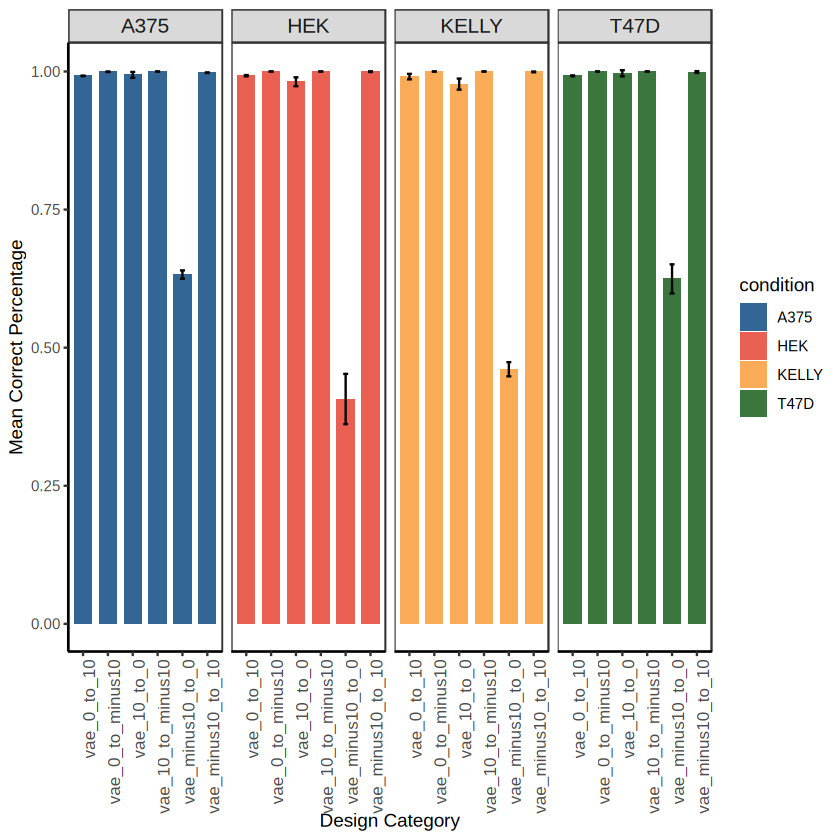

In [7]:
categories <- c("vae_0_to_minus10", "vae_0_to_10", "vae_minus10_to_0", "vae_minus10_to_10", "vae_10_to_0", "vae_10_to_minus10")

# vae_0_to_minus10
cat_shortlist_0_to_minus10 <- merged_back %>%
    filter(grepl("vae_0_to_minus10", design)) %>% 
    filter(abs(parent_PSI) <= 3) %>% 
    mutate(is_correct = ifelse((PSI < parent_PSI), "correct", "incorrect"))

results_0_to_minus10 <- cat_shortlist_0_to_minus10 %>% 
    group_by(sample, condition) %>% 
    summarise(correct_perc = sum(is_correct == "correct") / n()) %>%
    mutate(category = "vae_0_to_minus10")

# vae_0_to_10
cat_shortlist_0_to_10 <- merged_back %>%
    filter(grepl("vae_0_to_10", design)) %>% 
    filter(abs(parent_PSI) <= 3) %>% 
    mutate(is_correct = ifelse((PSI > parent_PSI), "correct", "incorrect"))

results_0_to_10 <- cat_shortlist_0_to_10 %>% 
    group_by(sample, condition) %>% 
    summarise(correct_perc = sum(is_correct == "correct") / n()) %>%
    mutate(category = "vae_0_to_10")

# vae_minus10_to_0
cat_shortlist_minus10_to_0 <- merged_back %>%
    filter(grepl("vae_minus10_to_0", design)) %>% 
    filter(parent_PSI <= -3) %>% 
    mutate(is_correct = ifelse(PSI > parent_PSI, "correct", "incorrect"))

results_minus10_to_0 <- cat_shortlist_minus10_to_0 %>% 
    group_by(sample, condition) %>% 
    summarise(correct_perc = sum(is_correct == "correct") / n()) %>%
    mutate(category = "vae_minus10_to_0")

# vae_minus10_to_10
cat_shortlist_minus10_to_10 <- merged_back %>%
    filter(grepl("vae_minus10_to_10", design)) %>% 
    filter(parent_PSI <= -3) %>% 
    mutate(is_correct = ifelse(PSI > parent_PSI, "correct", "incorrect"))

results_minus10_to_10 <- cat_shortlist_minus10_to_10 %>% 
    group_by(sample, condition) %>% 
    summarise(correct_perc = sum(is_correct == "correct") / n()) %>%
    mutate(category = "vae_minus10_to_10")

# vae_10_to_0
cat_shortlist_10_to_0 <- merged_back %>%
    filter(grepl("vae_10_to_0", design)) %>% 
    filter(parent_PSI >= 3) %>% 
    mutate(is_correct = ifelse(PSI < parent_PSI, "correct", "incorrect"))

results_10_to_0 <- cat_shortlist_10_to_0 %>% 
    group_by(sample, condition) %>% 
    summarise(correct_perc = sum(is_correct == "correct") / n()) %>%
    mutate(category = "vae_10_to_0")

# vae_10_to_minus10
cat_shortlist_10_to_minus10 <- merged_back %>%
    filter(grepl("vae_10_to_minus10", design)) %>% 
    filter(parent_PSI >= 3) %>% 
    mutate(is_correct = ifelse(PSI < parent_PSI, "correct", "incorrect"))

results_10_to_minus10 <- cat_shortlist_10_to_minus10 %>% 
    group_by(sample, condition) %>% 
    summarise(correct_perc = sum(is_correct == "correct") / n()) %>%
    mutate(category = "vae_10_to_minus10")


# Combine all results
all_results <- bind_rows(results_0_to_minus10, results_0_to_10, results_minus10_to_0, results_minus10_to_10, results_10_to_0, results_10_to_minus10)

# Calculate the mean and sd for each condition and category. 
all_results <- all_results %>% 
    group_by(category, condition) %>% 
    summarise(mean_correct_perc = mean(correct_perc), sd_correct_perc = sd(correct_perc))

color_palette3 <- c(
"#336695",
"#E96052",
"#F9AB57",
"#3b763e")

# Plot the results
ggplot(all_results, aes(x = category, y = mean_correct_perc, fill = condition)) +
    geom_bar(stat = "identity", position = "dodge", width = 0.7) +
    geom_errorbar(aes(ymin = mean_correct_perc - sd_correct_perc, 
                      ymax = mean_correct_perc + sd_correct_perc), 
                  width = 0.2, position = position_dodge(0.7)) +
    scale_fill_manual(values = color_palette3) +
    theme_bw() +
    facet_wrap(~condition, nrow = 1) +
    theme(axis.line = element_line(colour = "black"),
          panel.grid.major = element_blank(),
          panel.grid.minor = element_blank(), 
          panel.background = element_blank(),
          strip.text = element_text(size = 12)) +
    # Xlabel rotated 90 degrees
    theme(axis.text.x = element_text(angle = 90, hjust = 1, size = 10)) +
    xlab("Design Category") +
    ylab("Mean Correct Percentage") +
    labs(color = "Cell Line")


# Save the results
ggsave(file.path(figure_outdir, "fig06_correctness_metrics_increase_decrease_only.pdf"), width = 1200, height = 500, units = "px", dpi = 150)

# Now we plot for each group, the Parent PSI and designed PSI in box plots

,sample,condition,index_offset,design,INCLUDED,SKIPPED,total_counts,included_count_normalized,skipped_count_normalized,PSI,parent_PSI
,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<int>,<int>,<dbl>,<dbl>
1,A375-rep1,A375,ENSG00000001617.12;SEMA3F;chr3-50174051-50174114-50173792-50173953-50174230-50174350__0:0:0,vae_0_to_minus10_R1design1,0,76,76,0,1000,0.000000000,0.3888889
2,A375-rep1,A375,ENSG00000001617.12;SEMA3F;chr3-50174051-50174114-50173792-50173953-50174230-50174350__0:0:0,vae_0_to_10_R1design9,247,7,254,972,27,0.972440945,0.3888889
3,A375-rep1,A375,ENSG00000001617.12;SEMA3F;chr3-50174051-50174114-50173792-50173953-50174230-50174350__0:0:0,vae_0_to_10_R1design10,1377,53,1430,962,37,0.962937063,0.3888889
4,A375-rep1,A375,ENSG00000001617.12;SEMA3F;chr3-50174051-50174114-50173792-50173953-50174230-50174350__0:0:0,vae_0_to_minus10_R1design3,0,264,264,0,1000,0.000000000,0.3888889
5,A375-rep1,A375,ENSG00000001617.12;SEMA3F;chr3-50174051-50174114-50173792-50173953-50174230-50174350__0:0:0,vae_0_to_minus10_R1design2,1,626,627,1,998,0.001594896,0.3888889
6,A375-rep1,A375,ENSG00000001617.12;SEMA3F;chr3-50174051-50174114-50173792-50173953-50174230-50174350__0:0:0,vae_0_to_10_R1design14,808,20,828,975,24,0.975845411,0.3888889


Warning message:
“Removed 633 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 533 rows containing missing values or values outside the scale range
(`geom_point()`).”


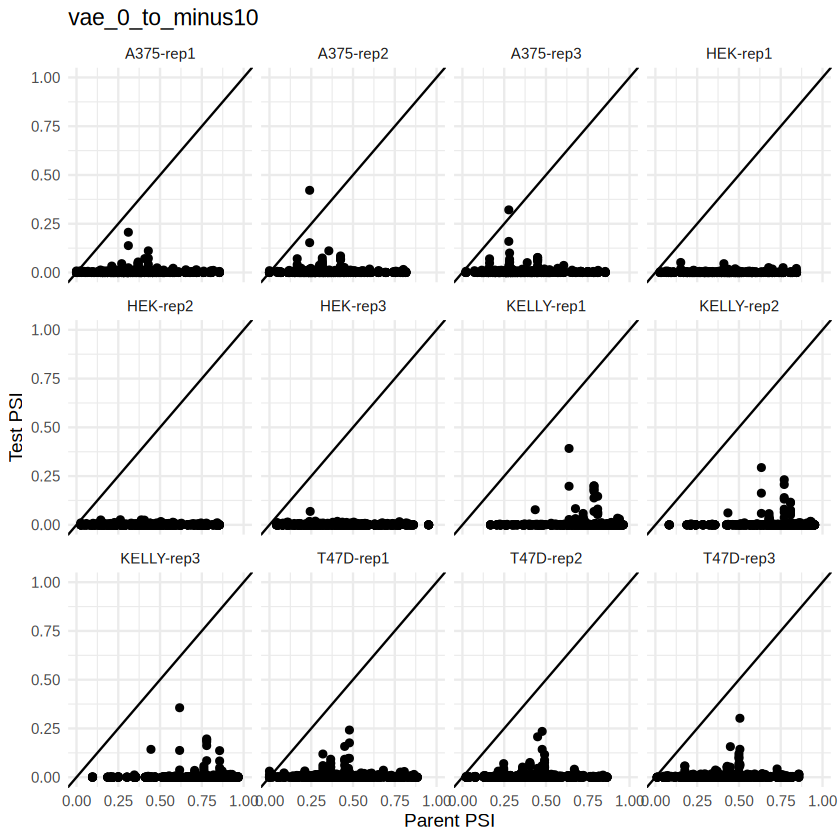

Warning message:
“Removed 2956 rows containing missing values or values outside the scale range
(`geom_point()`).”


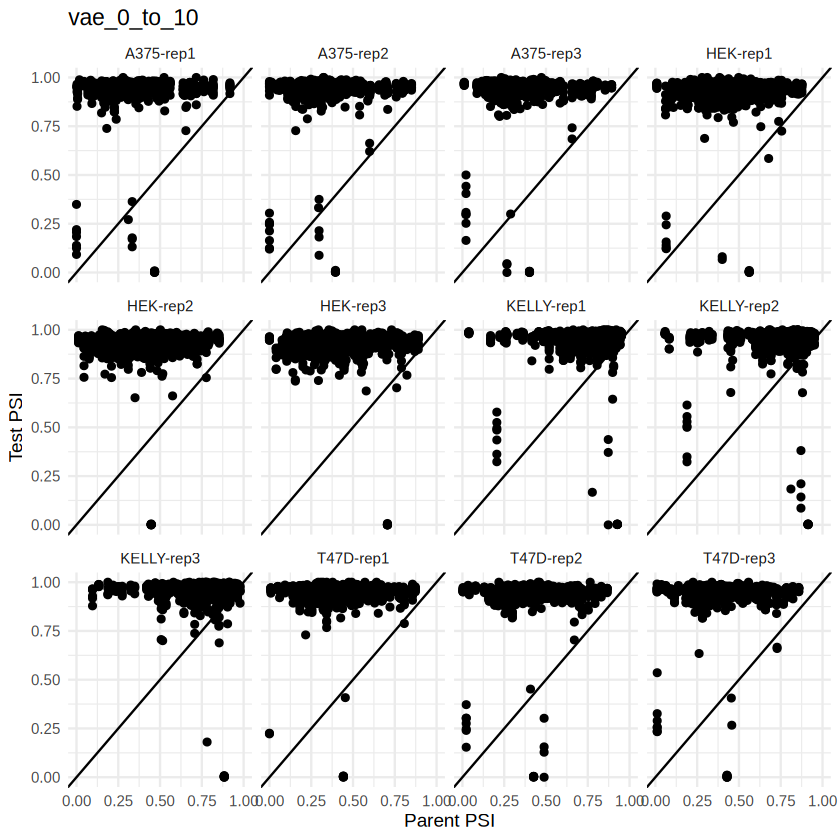

Warning message:
“Removed 4066 rows containing missing values or values outside the scale range
(`geom_point()`).”


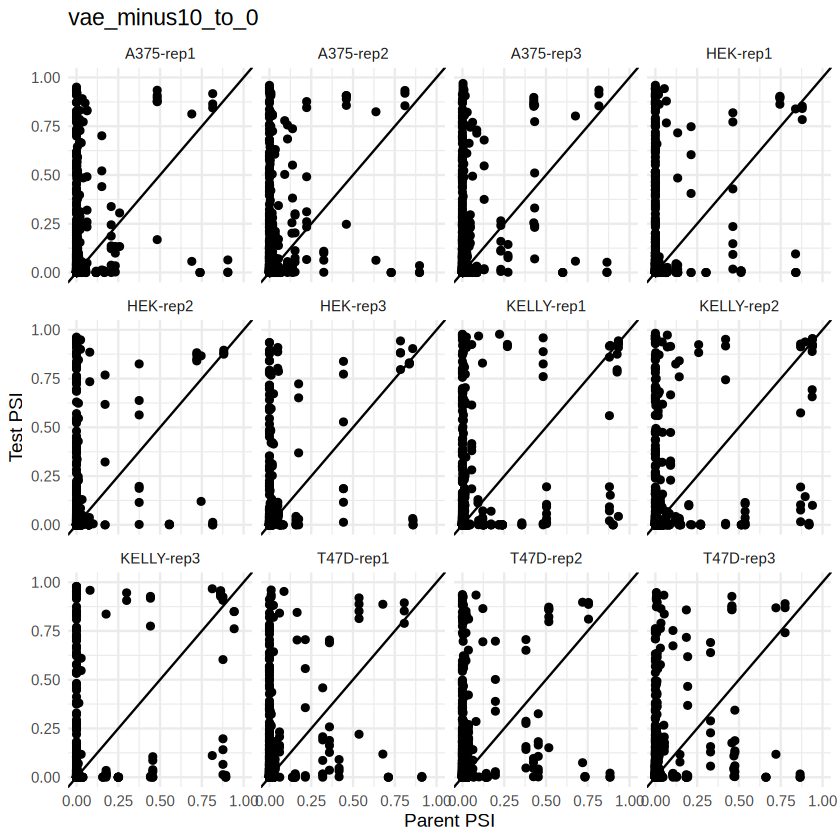

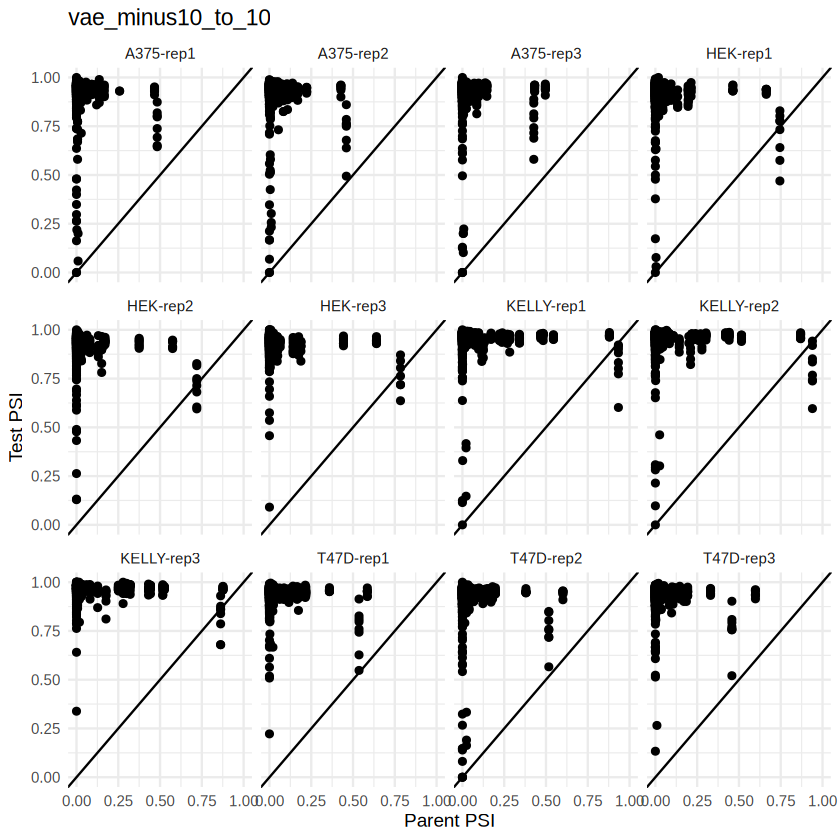

Warning message:
“Removed 59 rows containing missing values or values outside the scale range
(`geom_point()`).”


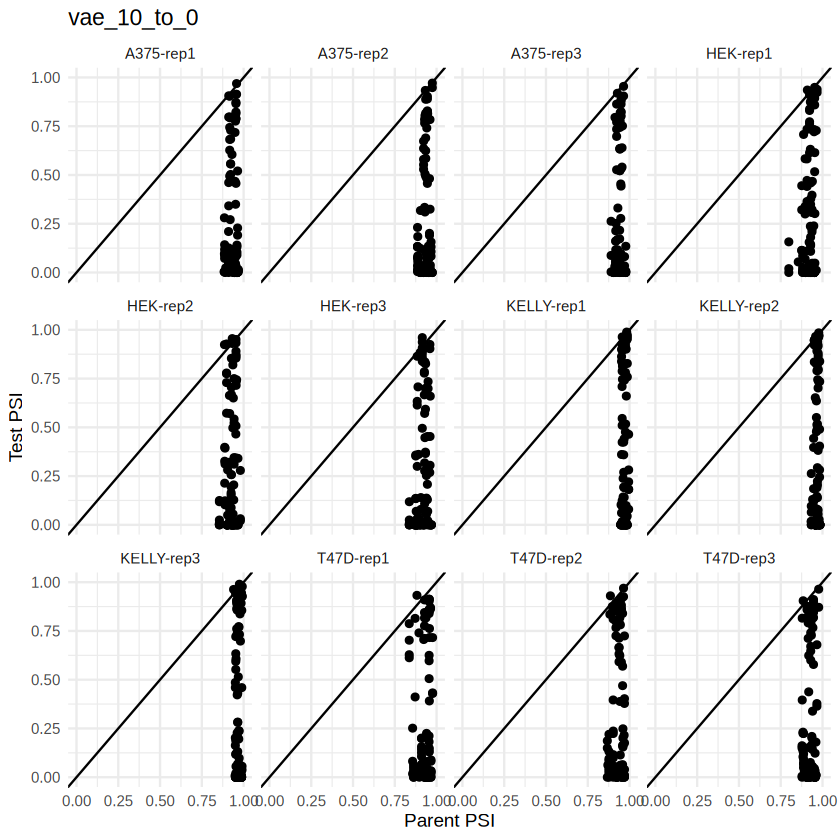

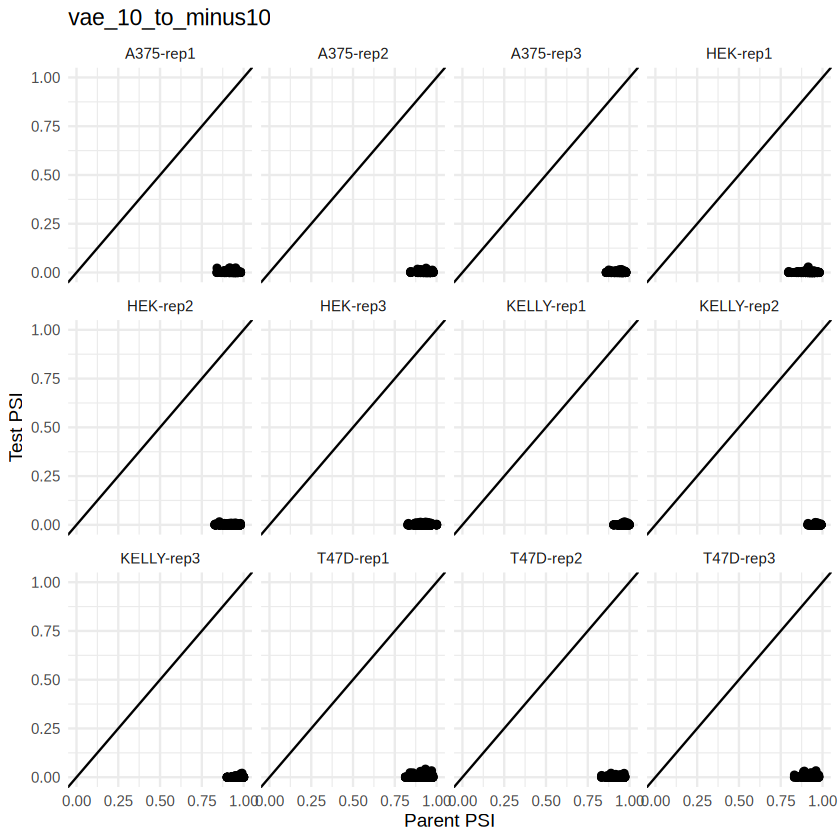

In [36]:
# Get the standard set. 
standard_set <- raw_df_to_psi %>% 
    filter(design == "R1design0") %>% 
    mutate(PSI = INCLUDED/(INCLUDED+SKIPPED)) %>% 
    mutate(parent_PSI = PSI) %>%
    select(sample, condition, index_offset, parent_PSI)
    
test_set <- raw_df_to_psi %>% 
    mutate(PSI = INCLUDED/(INCLUDED+SKIPPED)) %>% 
    filter(design != "R1design0") 

merged_back <- merge(test_set, standard_set, by = c("sample", "condition", "index_offset"), all.x = TRUE)
head(merged_back)


categories <- c("vae_0_to_minus10", "vae_0_to_10", "vae_minus10_to_0", "vae_minus10_to_10", "vae_10_to_0", "vae_10_to_minus10")

# Loop through each category and create/save plots
for(category_current in categories) {
    data_current <- merged_back %>%
        filter(grepl(category_current, design))
    
    p <- ggplot(data_current, aes(x = parent_PSI, y = PSI)) +
        geom_point() +
        geom_abline(slope = 1, intercept = 0) +
        theme_minimal() +
        labs(x = "Parent PSI", y = "Test PSI") +
        ggtitle(category_current) + 
        facet_wrap(~sample) +
        ylim(0,1) +
        xlim(0,1)
    # Display plot in notebook
    print(p)
}

merged_back_pivot_longer <- merged_back %>% 
pivot_longer(cols = c(PSI, parent_PSI), names_to = "type", values_to = "PSI") 
# group_by(condition, index_offset, design, type) %>%
# summarise(PSI = mean(PSI))

# Add the categories to the merged_back_pivot_longer
categories <- c("vae_0_to_minus10", "vae_0_to_10", "vae_minus10_to_0", "vae_minus10_to_10", "vae_10_to_0", "vae_10_to_minus10")
merged_back_pivot_longer <- merged_back_pivot_longer %>% 
mutate(category = case_when(
    grepl("vae_0_to_minus10", design) ~ "vae_0_to_minus10",
    grepl("vae_0_to_10", design) ~ "vae_0_to_10",
    grepl("vae_minus10_to_0", design) ~ "vae_minus10_to_0",
    grepl("vae_minus10_to_10", design) ~ "vae_minus10_to_10",
    grepl("vae_10_to_0", design) ~ "vae_10_to_0",
    grepl("vae_10_to_minus10", design) ~ "vae_10_to_minus10",
    TRUE ~ "other"
))

In [34]:
nrow(merged_back_pivot_longer)

[1] 45354

Warning message:
“Removed 8247 rows containing non-finite outside the scale range
(`stat_boxplot()`).”
Warning message:
“Removed 8247 rows containing non-finite outside the scale range
(`stat_boxplot()`).”


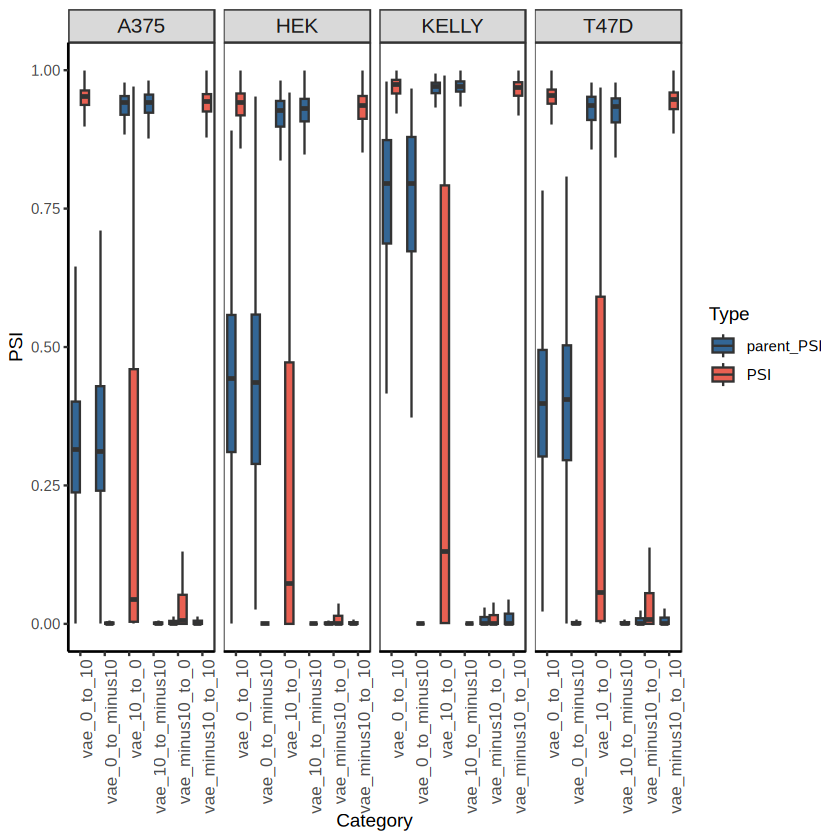

In [47]:
color_palette3 <- c(
"#336695",
"#E96052",
"#F9AB57",
"#3b763e")

ggplot(merged_back_pivot_longer, aes(x = category, y = PSI, fill = type)) +
  geom_boxplot(outlier.shape = NA) +
  theme_bw() +
  facet_wrap(~condition, nrow = 1) +
  theme(axis.line = element_line(colour = "black"),
        panel.grid.major = element_blank(),
        panel.grid.minor = element_blank(),
        panel.background = element_blank(),
        strip.text = element_text(size = 12),
        axis.text.x = element_text(angle = 90, hjust = 1, size = 10)) +
  xlab("Category") +
  ylab("PSI") +
  labs(fill = "Type") +
  scale_fill_manual(values = color_palette3) +
  scale_x_discrete(expand = expansion(mult = c(0.1, 0.1)))


ggsave(file.path(figure_outdir, "fig06_PSI_by_group.pdf"), width = 1800, height = 500, units = "px", dpi = 150)